# Tarea Semanal 6
## Autor: Pedro Guzman


## Consigna 
En el repositorio [PDStestbench](#) encontrará tres tipos de señales registradas:

- **Electrocardiograma (ECG).** En el archivo **ECG_TP4.mat** encontrará un registro electrocardiográfico (ECG) registrado durante una prueba de esfuerzo, junto con una serie de variables descriptas más abajo.
- **Pletismografía (PPG).** El archivo PPG.csv contiene una señal registrada en reposo de un estudiante de la materia que ha donado su registro para esta actividad.
- **Audio**. Tres registros en los que el profesor pronuncia una frase, y otros dos en los que se silba una melodía muy conocida.

Los detalles de cómo acceder a dichos registros los pueden encontrar en [lectura_sigs.py](#)

Se pide:

**1)** Realizar la estimación de la densidad espectral de potencia (PSD) de cada señal mediante alguno de los métodos vistos en clase (Periodograma ventaneado, Welch, Blackman-Tukey).

2) Realice una estimación del ancho de banda de cada señal y presente los resultados en una tabla para facilitar la comparación.

Bonus:

- 💎 Proponga algún tipo de señal que no haya sido analizada y repita el análisis. No olvide explicar su origen y cómo fue digitalizada.
 



## Solucion Propuesta

Se realizan varias funciones de manera de poder cada señal de distinta fuente de manera rapida y eficaz, sin importar la procedencia de la señal.

En Blacman-Tukey saque la Autocorrelacion utilizando la FFT debido a que si utilizo la autocorrelacion mediante el uso la funcion np.correlate, ya que si no la computadora sufria con la cantidad de operaciones realizadas para sacar la autocorrelacion

https://gist.github.com/ajkluber/f293eefba2f946f47bfa
https://dsp.stackexchange.com/questions/70152/computing-autocorrelation-via-fft
https://dsp.stackexchange.com/questions/98071/autocorrelation-via-fft
https://stackoverflow.com/questions/3949324/calculate-autocorrelation-using-fft-in-matlab

Se ve que en muchos casos se usa Zero Padding para hacer laa autocorrelacion VIA FFT, en este caso no hace falta debido a que los lags menores a N/2 no se corrompen, es como si fuera un Aliasing Circular, pero no nos afecta debido a que agarramos 1<M<N//5 

In [1]:
import pandas as pd
from scipy.io import wavfile, loadmat, whosmat
import numpy as np
from scipy.signal import windows as win
import matplotlib.pyplot as plt
import scipy.signal as sp



def blackman_tukey(x, fs=1, M=None, window='blackman'):
    """
    Estima la Densidad Espectral de Potencia (PSD) usando el método de Blackman-Tukey.
    
    El método consiste en:
        1. Calcular la autocorrelación de la señal (via FFT para eficiencia)
        2. Truncar la autocorrelación a M lags
        3. Aplicar una ventana sobre la autocorrelación truncada
        4. Calcular la FFT de la autocorrelación ventaneada
    
    Args:
        x      : señal de entrada (array 1D o 2D, se aplana automáticamente)
        fs     : frecuencia de muestreo en Hz (default: 1)
        M      : número de lags de la autocorrelación. Controla el balance entre
                 resolución frecuencial (M grande) y varianza del estimador (M chico).
                 Default: N//5
        window : ventana a aplicar sobre la autocorrelación. Cualquier ventana
                 válida de scipy.signal.windows (default: 'blackman')
    
    Returns:
        f_half   : array de frecuencias positivas [0, fs/2] en Hz
        psd_half : array con la PSD estimada en V²/Hz
    """
    # Aplanar a 1D y convertir a float64 para evitar overflow en operaciones
    x = x.ravel().astype(float)
    N = len(x)

    if M is None:
        M = N // 5

    # --- Autocorrelación via FFT ---
    # Equivalente a np.correlate(x, x, mode='full') pero O(N log N) en vez de O(N²)
    # Dividimos por (N * fs) para normalizar: N por el largo de la señal, fs para
    # que el resultado quede en unidades de V²/Hz al integrar
    X = np.fft.fft(x)
    xcorr_full = np.fft.ifft(X * np.conj(X)).real / (N * fs)

    # --- Truncado a M lags ---
    # xcorr_full[0]       = lag 0
    # xcorr_full[1..M-1]  = lags positivos 1 a M-1
    # xcorr_full[N-M+1..] = lags negativos -(M-1) a -1 (por periodicidad de la FFT)
    # Armamos el vector simétrico: [-(M-1), ..., 0, ..., (M-1)]
    r = np.concatenate([xcorr_full[N-(M-1):], xcorr_full[:M]])

    # --- Ventaneo de la autocorrelación ---
    # La ventana reduce el efecto de los lags extremos (menos confiables por tener
    # menos muestras para promediar), reduciendo el leakage espectral
    ventana = win.get_window(window, len(r))
    r_windowed = r * ventana

    # --- FFT de la autocorrelación ventaneada ---
    # Usamos n=N para que la resolución frecuencial sea fs/N Hz/bin
    psd = np.abs(np.fft.fft(r_windowed, n=N))

    # --- Quedarse solo con frecuencias positivas [0, fs/2] ---
    f = np.fft.fftfreq(N, d=1/fs)
    mitad = f >= 0
    f_half = f[mitad]
    psd_half = psd[mitad]

    # Duplicar frecuencias positivas (excepto DC) para conservar la potencia total,
    # ya que descartamos la mitad negativa del espectro
    psd_half[1:] *= 2

    return f_half, psd_half


def potencia_acumulada(f, psd):
    """
    Calcula la potencia acumulada en función de la frecuencia integrando la PSD.

    Aplica el teorema de Parseval en forma discreta:
        P(f) = sum(PSD[0..f]) * df

    donde df = f[1] - f[0] es el espaciado entre bins de frecuencia.
    El último valor del array resultante es la potencia total de la señal.

    Args:
        f   : array de frecuencias en Hz
        psd : array de PSD en V²/Hz, mismo largo que f

    Returns:
        P_acum : array de potencia acumulada en V², mismo largo que f.
                 P_acum[-1] = potencia total de la señal.
    """
    df = f[1] - f[0]          # espaciado entre bins [Hz]
    P_acum = np.cumsum(psd) * df  # integración discreta (regla del rectángulo)
    return P_acum


def plot_psd(signal, fs, titulo):
    """
    Estima y grafica la PSD de una señal usando 5 métodos, y compara la
    potencia total y el ancho de banda al 95% entre ellos.

    Genera dos figuras:
        1. PSD en escala logarítmica (semilogy) con los 5 métodos superpuestos
        2. Panel comparativo con:
              - Izquierda: potencia acumulada normalizada (0-100%) vs frecuencia,
                           con línea punteada en 95%
              - Derecha:   barras dobles de potencia total [V²] y BW al 95% [Hz]
                           para cada método

    También imprime una tabla resumen con potencia total y BW al 95% por método,
    más la potencia calculada directamente en el dominio del tiempo como referencia.

    Args:
        signal : señal de entrada (array 1D o 2D, se aplana automáticamente)
        fs     : frecuencia de muestreo en Hz
        titulo : string que aparece como título en los gráficos y en el print
    """
    signal = signal.ravel().astype(float)
    N = len(signal)

    # --- Estimación de PSD con cada método ---
    # Welch con segmentos grandes: mejor resolución frecuencial, más varianza
    f1, P1 = sp.welch(signal, fs, window='hann', nperseg=N//5)

    # Welch default (nperseg=256): puede dar mala resolución si fs es baja
    f2, P2 = sp.welch(signal, fs, window='hann')

    # Blackman-Tukey: autocorrelación ventaneada, buen balance sesgo-varianza
    f3, P3 = blackman_tukey(signal, fs=fs)

    f5, P5 = blackman_tukey(signal, M=N//20 , fs=fs)
    
    # Periodograma ventaneado: alta resolución pero alta varianza (ruidoso)
    f4, P4 = sp.periodogram(signal, fs, window='hann')

    metodos = [
        (f4, P4, 'Periodogram'),
        (f3, P3, 'Blackman-Tukey, M=N/5'),
        (f1, P1, 'Welch nperseg=N/5'),
        (f5, P5, 'Blackman-Tukey, M=N//20'),
        (f2, P2, 'Welch default'),
    ]

    # --- Figura 1: PSD ---
    fig, ax = plt.subplots()
    for f, P, label in metodos:
        ax.semilogy(f, P, label=label)
    ax.set_title(titulo)
    ax.set_xlabel('frequency [Hz]')
    ax.set_ylabel('PSD [V**2/Hz]')
    ax.legend()
    ax.grid()
    plt.show()

    # --- Figura 2: Potencia acumulada comparativa ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Potencia acumulada - {titulo}')

    P_totales = []
    f_95s = []

    for f, P, label in metodos:
        P_acum = potencia_acumulada(f, P)
        P_total = P_acum[-1]
        # Frecuencia donde se alcanza el 95% de la potencia total (ancho de banda)
        f_95 = f[np.argmax(P_acum >= 0.95 * P_total)]
        P_totales.append(P_total)
        f_95s.append(f_95)
        # Normalizar a porcentaje para comparar métodos con distintas escalas
        axes[0].plot(f, P_acum / P_total * 100, label=label)

    axes[0].axhline(95, color='k', linestyle='--', label='95%')
    axes[0].set_xlabel('Frecuencia [Hz]')
    axes[0].set_ylabel('Potencia acumulada [%]')
    axes[0].set_title('Potencia acumulada normalizada')
    axes[0].legend()
    axes[0].grid()

    # Barras dobles: potencia total (azul) y BW al 95% (naranja)
    # Usan ejes Y distintos porque tienen unidades diferentes (V² vs Hz)
    labels = [m[2] for m in metodos]
    x = np.arange(len(labels))
    width = 0.35

    ax2 = axes[1]
    ax2.bar(x - width/2, P_totales, width, label='P total [V²]')
    ax2.set_ylabel('Potencia total [V²]')
    ax2.set_title('Potencia total y BW al 95%')
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels, rotation=15, ha='right')
    ax2.legend(loc='upper left')
    ax2.grid(axis='y')

    ax3 = ax2.twinx()   # segundo eje Y sobre el mismo gráfico
    ax3.bar(x + width/2, f_95s, width, color='orange', label='BW 95% [Hz]')
    ax3.set_ylabel('Ancho de banda 95% [Hz]')
    ax3.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    # --- Print resumen ---
    # Potencia en tiempo via Parseval: mean(x²), sirve como referencia para
    # verificar que la normalización de la PSD es correcta
    P_tiempo = np.mean(signal**2)
    print(f"\n[{titulo}]  P tiempo = {P_tiempo:.8f} V²")
    print(f"  {'Método':<45} {'P total [V²]':>15} {'BW 95% [Hz]':>12}")
    print(f"  {'-'*75}")
    for (_, _, label), P_tot, f95 in zip(metodos, P_totales, f_95s):
        print(f"  {label:<45} {P_tot:>15.8f} {f95:>12.3f}")

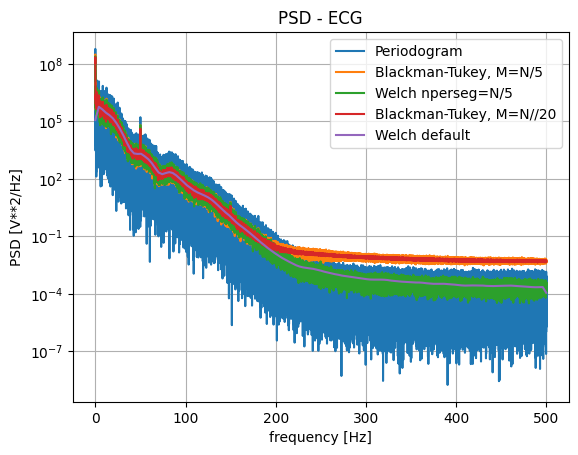

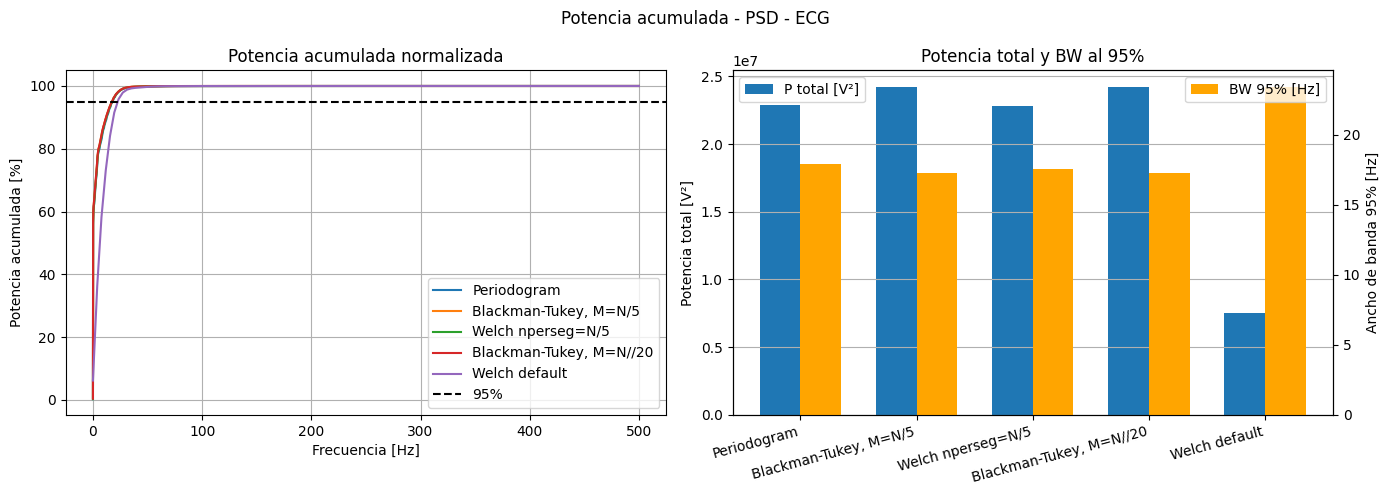


[PSD - ECG]  P tiempo = 24239433.84090209 V²
  Método                                           P total [V²]  BW 95% [Hz]
  ---------------------------------------------------------------------------
  Periodogram                                   22883921.78801344       17.943
  Blackman-Tukey, M=N/5                         24239433.84045480       17.309
  Welch nperseg=N/5                             22819266.34930425       17.536
  Blackman-Tukey, M=N//20                       24239433.83341872       17.310
  Welch default                                 7547878.77246328       23.438


In [2]:
# --- MAT ---
fs_mat = 1000 ##Estaba en el archivo de registro
mat_struct = loadmat('./ECG_TP4.mat')
ecg_one_lead = mat_struct['ecg_lead'].flatten()
N = len(ecg_one_lead)
t_ecg = np.arange(N) / fs_mat
hb_1 = mat_struct['heartbeat_pattern1'] ##Ni lo use
hb_2 = mat_struct['heartbeat_pattern2'] ##Ni lo use
plot_psd(ecg_one_lead, fs_mat,    'PSD - ECG')

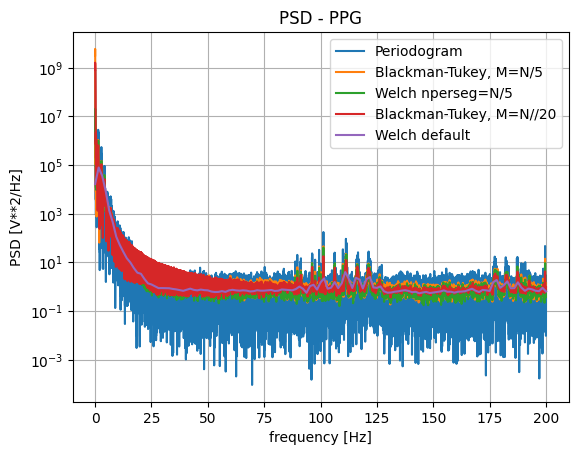

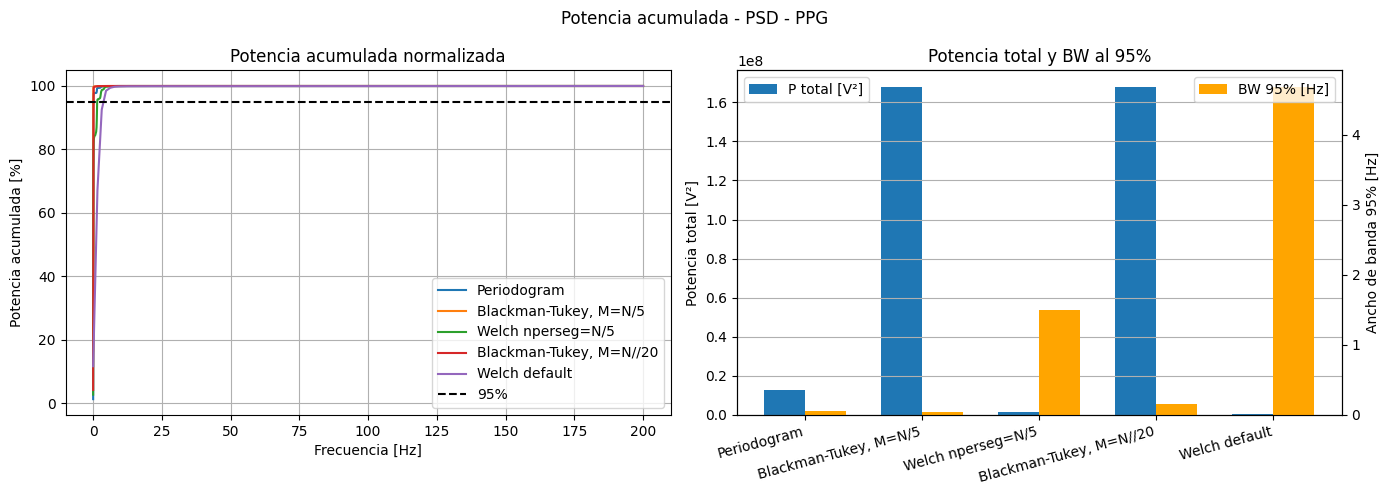


[PSD - PPG]  P tiempo = 167685386.24424633 V²
  Método                                           P total [V²]  BW 95% [Hz]
  ---------------------------------------------------------------------------
  Periodogram                                   12958188.09876479        0.053
  Blackman-Tukey, M=N/5                         167724276.58260599        0.035
  Welch nperseg=N/5                             1677818.08673370        1.501
  Blackman-Tukey, M=N//20                       167976981.76747912        0.159
  Welch default                                 220421.63016493        4.688


In [3]:
ppg = np.genfromtxt('PPG.csv', delimiter=',', skip_header=1)
fs_ppg = 400 ##Estaba en el archivo de registro
plot_psd(ppg,          fs_ppg,    'PSD - PPG')

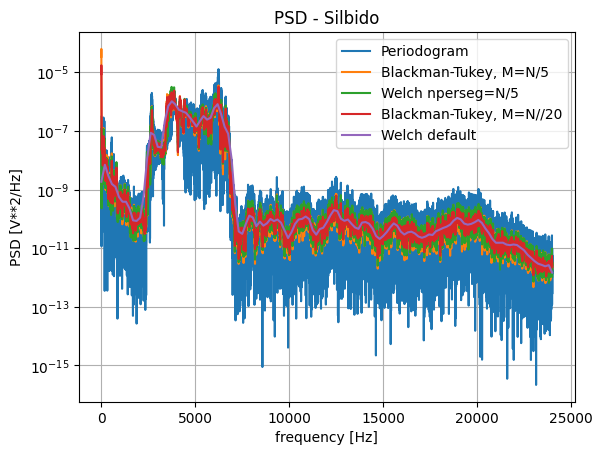

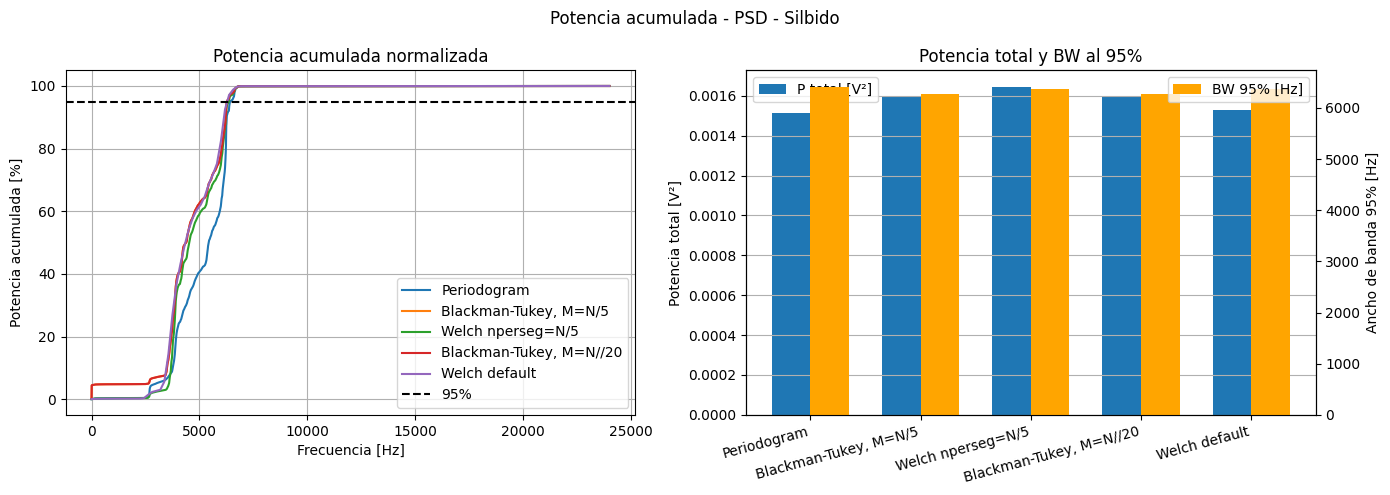


[PSD - Silbido]  P tiempo = 0.00160055 V²
  Método                                           P total [V²]  BW 95% [Hz]
  ---------------------------------------------------------------------------
  Periodogram                                        0.00151178     6414.000
  Blackman-Tukey, M=N/5                              0.00160055     6274.000
  Welch nperseg=N/5                                  0.00164570     6368.333
  Blackman-Tukey, M=N//20                            0.00160055     6273.667
  Welch default                                      0.00152822     6375.000


In [4]:
# --- WAVs ---
fs_silbido, silbido     = wavfile.read('silbido.wav')
plot_psd(silbido,      fs_silbido,    'PSD - Silbido')

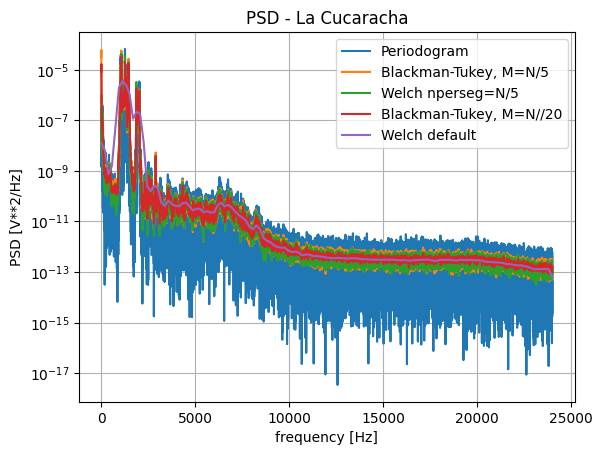

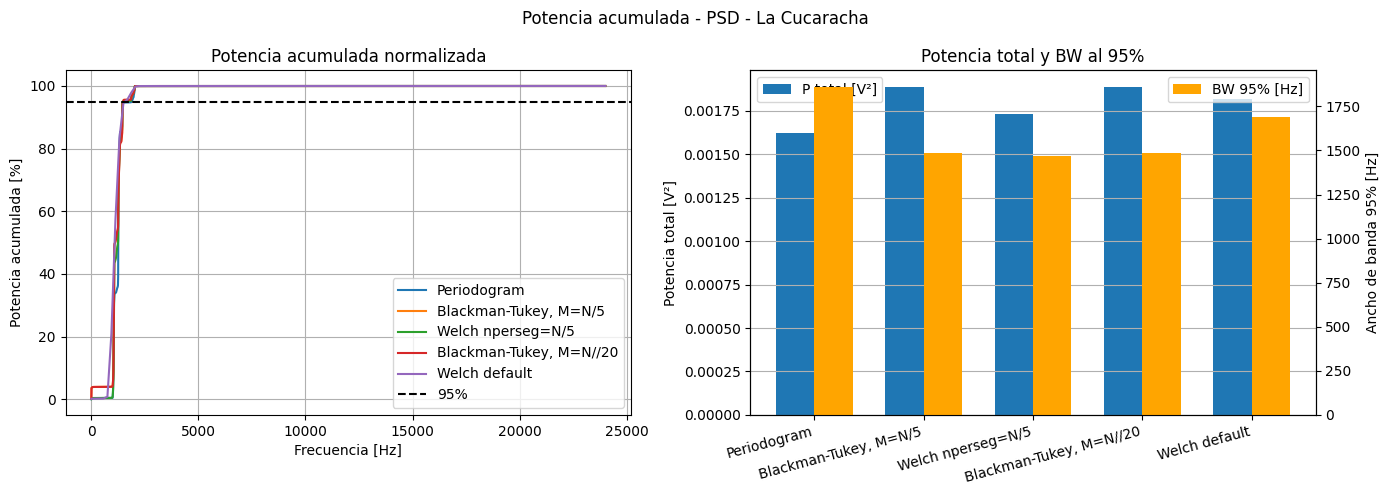


[PSD - La Cucaracha]  P tiempo = 0.00188961 V²
  Método                                           P total [V²]  BW 95% [Hz]
  ---------------------------------------------------------------------------
  Periodogram                                        0.00162443     1861.667
  Blackman-Tukey, M=N/5                              0.00188961     1487.000
  Welch nperseg=N/5                                  0.00172984     1470.000
  Blackman-Tukey, M=N//20                            0.00188961     1487.333
  Welch default                                      0.00182005     1687.500


In [5]:
fs_cucaracha, cucaracha = wavfile.read('la cucaracha.wav')


plot_psd(cucaracha,    fs_cucaracha,  'PSD - La Cucaracha')

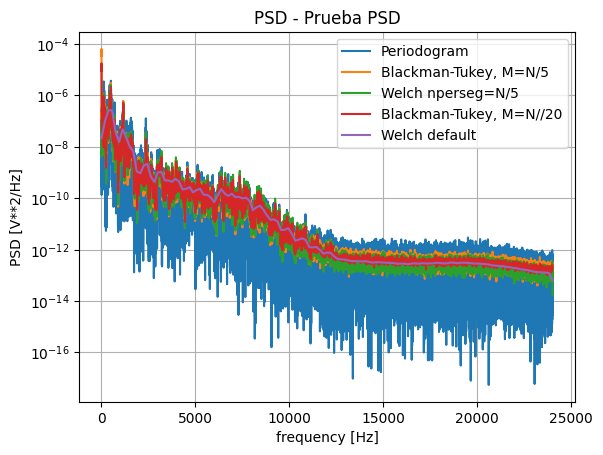

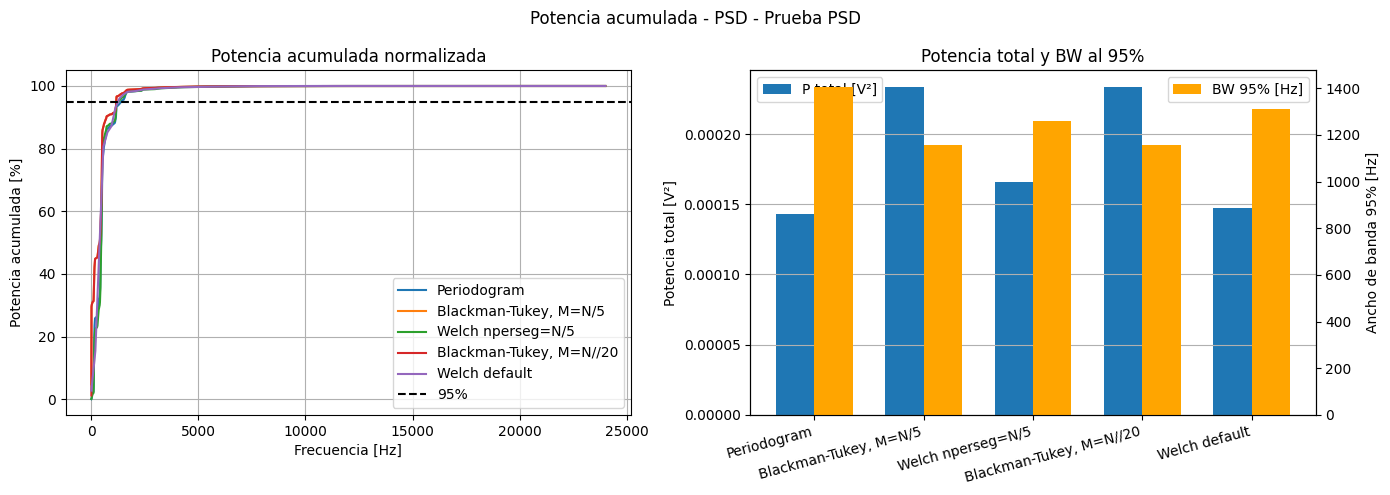


[PSD - Prueba PSD]  P tiempo = 0.00023377 V²
  Método                                           P total [V²]  BW 95% [Hz]
  ---------------------------------------------------------------------------
  Periodogram                                        0.00014287     1406.667
  Blackman-Tukey, M=N/5                              0.00023377     1158.667
  Welch nperseg=N/5                                  0.00016575     1258.333
  Blackman-Tukey, M=N//20                            0.00023377     1158.667
  Welch default                                      0.00014711     1312.500


In [6]:
fs_prueba, prueba_psd   = wavfile.read('prueba psd.wav')
plot_psd(prueba_psd,   fs_prueba,     'PSD - Prueba PSD')

### Bonus Señal de Telefono

La señal de este bonus es una señal de discado de telefono de la letra Numero 1, la misma la tenia desde que curse la materia de medidas e hicimos la calibracion del discado del telefono y verificacion del cumplimiento de la norma. El ensayo del discado del telefono se hizo siguiendo lo desarrollado por la Norma técnica CNC-St2-44.01 V02.1.1 secciones 13 (Condiciones de ensayo), 14.1 (Puentes de alimentación) y 21.2 (Marcación multifrecuente).

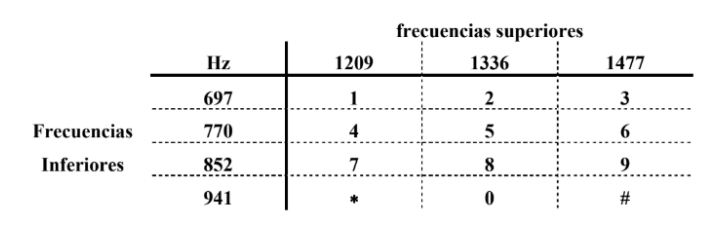

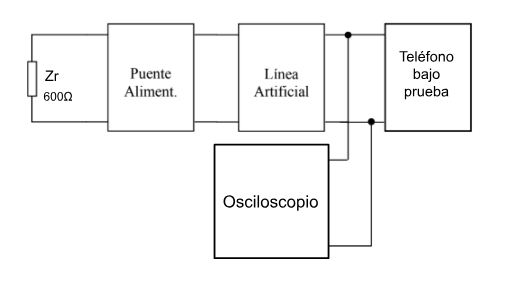

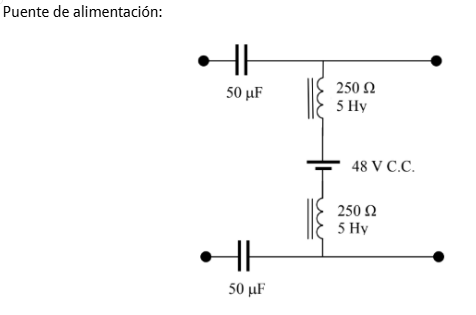

La señal fue digitalizada mediante el ADC del osciloscopio y su respectiva frecuencia de muestreo a una determinada base de tiempo, se pulso la tecla del telefono hasta tener todos los datos en la memoria del osciloscopio y despues se extrajo la señal utilizando un USB para obtener el archivo .CSV, se repitio lo mismo para cad tecla en este caso solo utilizamos la tecla NUM 1

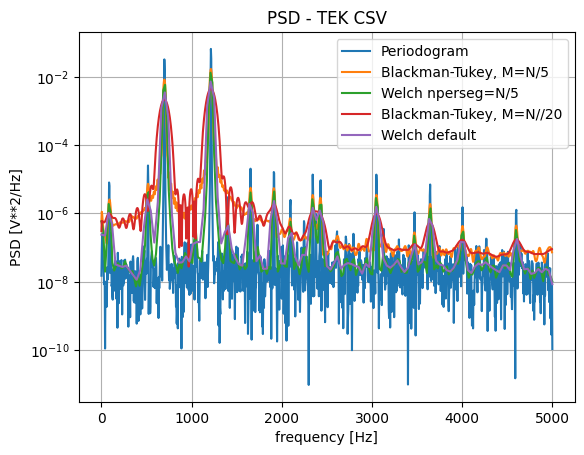

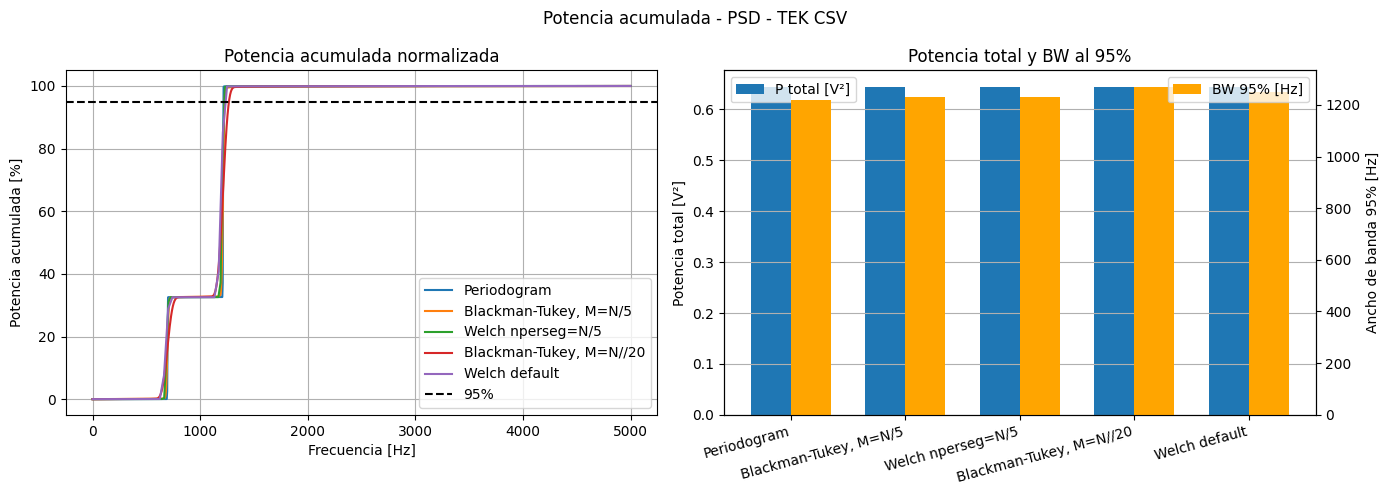


[PSD - TEK CSV]  P tiempo = 0.64439597 V²
  Método                                           P total [V²]  BW 95% [Hz]
  ---------------------------------------------------------------------------
  Periodogram                                        0.64445977     1217.742
  Blackman-Tukey, M=N/5                              0.64439554     1229.839
  Welch nperseg=N/5                                  0.64423677     1229.839
  Blackman-Tukey, M=N//20                            0.64459228     1270.161
  Welch default                                      0.64440692     1250.000


In [7]:
# --- CSVs ---
tecla1 = np.genfromtxt(r"TEK0000.CSV", delimiter=",", usecols=(3,4))
num1 = tecla1[20:, 1]
t = tecla1[20:, 0] ##Con esto saco la frecuencia de muestreo
plot_psd(num1,         1/(t[2]-t[1]),     'PSD - TEK CSV')

Se puede ver como la potencia acumulada normalizada es escalonada, lo que tiene sentido debido a la amplitud de las deltas de los tonos de discado de telefono, justo despues de la delta a frecuencia superior.